# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [37]:
# importo las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
# cargo el dataset
seattle = pd.read_csv('temps.csv')

### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [39]:
# primer vistazo al dataset
seattle.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            348 non-null    int64  
 1   month           348 non-null    int64  
 2   day             348 non-null    int64  
 3   week            348 non-null    str    
 4   temp_2          348 non-null    int64  
 5   temp_1          348 non-null    int64  
 6   average         348 non-null    float64
 7   actual          348 non-null    int64  
 8   forecast_noaa   348 non-null    int64  
 9   forecast_acc    348 non-null    int64  
 10  forecast_under  348 non-null    int64  
 11  friend          348 non-null    int64  
dtypes: float64(1), int64(10), str(1)
memory usage: 32.8 KB


In [40]:
# miro las estadísticas del dataset
seattle.describe()

,year,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend
count,348.0,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000,348.000000
mean,2016.0,6.477011,15.514368,62.652299,62.701149,59.760632,62.543103,57.238506,62.373563,59.772989,60.034483
std,0.0,3.498380,8.772982,12.165398,12.120542,10.527306,11.794146,10.605746,10.549381,10.705256,15.626179
min,2016.0,1.000000,1.000000,35.000000,35.000000,45.100000,35.000000,41.000000,46.000000,44.000000,28.000000
25%,2016.0,3.000000,8.000000,54.000000,54.000000,49.975000,54.000000,48.000000,53.000000,50.000000,47.750000
50%,2016.0,6.000000,15.000000,62.500000,62.500000,58.200000,62.500000,56.000000,61.000000,58.000000,60.000000
75%,2016.0,10.000000,23.000000,71.000000,71.000000,69.025000,71.000000,66.000000,72.000000,69.000000,71.000000
max,2016.0,12.000000,31.000000,117.000000,117.000000,77.400000,92.000000,77.000000,82.000000,79.000000,95.000000


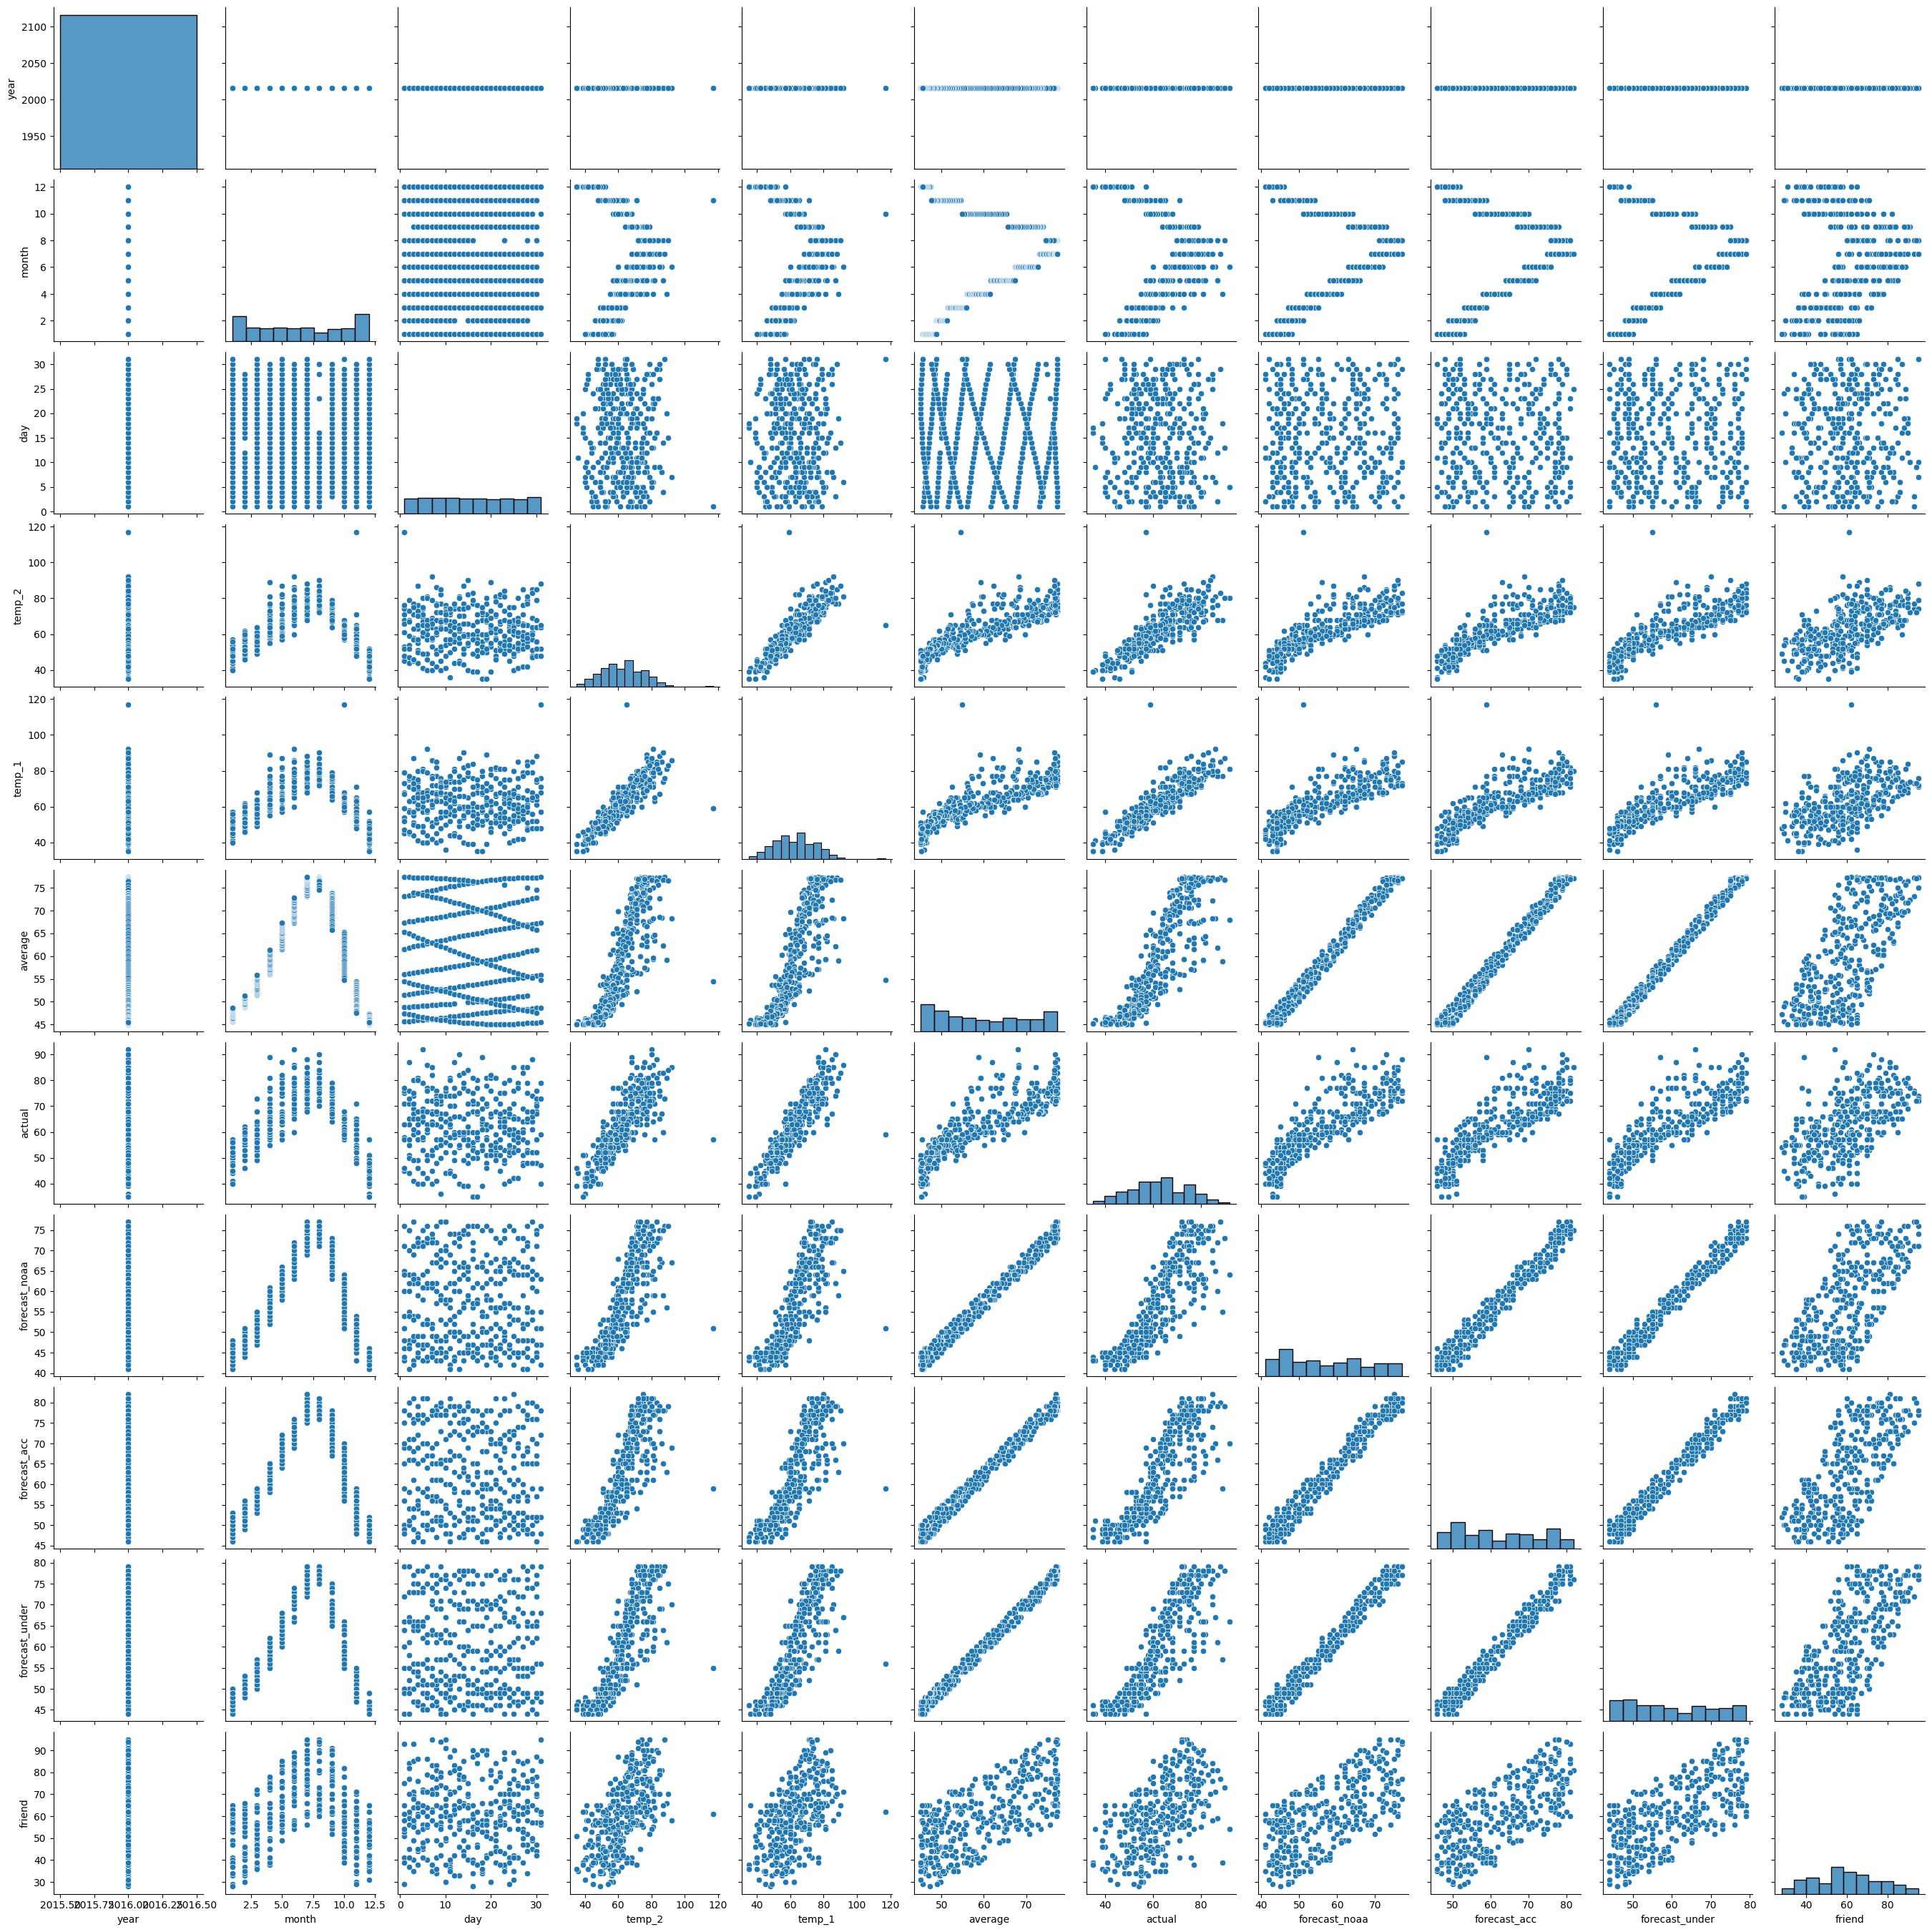

In [43]:
# creo un pairplot para ver las relaciones entre las variables
sns.pairplot(seattle)

<Axes: >

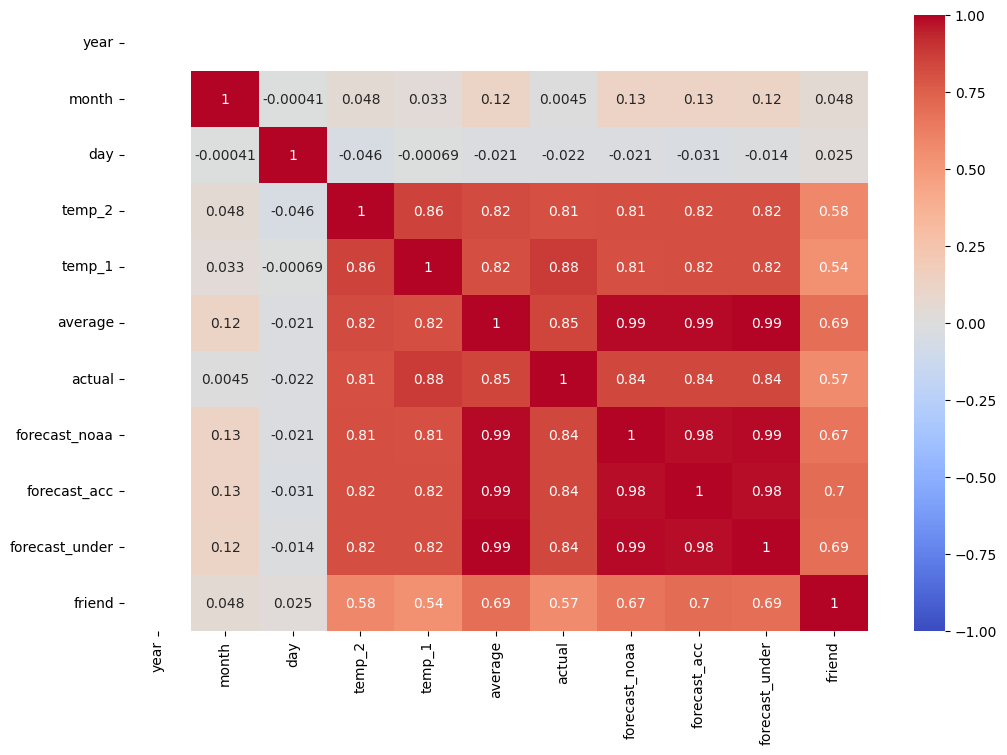

In [45]:
# creo el mapa de calor para ver las correlaciones entre las variables
plt.figure(figsize=(12, 8))
sns.heatmap(seattle.corr(numeric_only=True), annot=True, cmap='coolwarm', vmin=-1)   

#### La columna year se puede quitar perfectamente. La variable week se puede convertir a número con un one hot encoding.

In [46]:
# elimino la columna "year" porque no me aporta nada para el análisis
seattle = seattle.drop("year", axis=1)

In [47]:
# convierto la columna "week" en varias columnas con valores binarios (0 o 1) para cada semana
seattle = pd.get_dummies(seattle, columns=["week"])

In [48]:
seattle.head()

,month,day,temp_2,temp_1,average,actual,forecast_noaa,forecast_acc,forecast_under,friend,week_Fri,week_Mon,week_Sat,week_Sun,week_Thurs,week_Tues,week_Wed
0,1,1,45,45,45.6,45,43,50,44,29,True,False,False,False,False,False,False
1,1,2,44,45,45.7,44,41,50,44,61,False,False,True,False,False,False,False
2,1,3,45,44,45.8,41,43,46,47,56,False,False,False,True,False,False,False
3,1,4,44,41,45.9,40,44,48,46,53,False,True,False,False,False,False,False
4,1,5,41,40,46.0,44,46,46,46,41,False,False,False,False,False,True,False


#### Ahora tengo la columna year eliminada, la columna week también fuera y 7 columnas nuevas

### 3. Selecciona variables y divide en train y test

In [49]:
# separo las variables
X = seattle.drop('actual', axis=1)
y = seattle['actual']

In [52]:
# importo la función para dividir el dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split
# divido el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [53]:
# miro el tamaño de los conjuntos de entrenamiento y prueba
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 16)
(70, 16)
(278,)
(70,)


### 4. Entrena el modelo


#### Empiezo por entrenar con un arbol de regresion, ya que intentamos predecir un valor numérico. De momento, lo hago sin restricciones a ver que pasa

In [54]:
# importo el modelo de árbol de decisión para regresión
from sklearn.tree import DecisionTreeRegressor
# traigo el modelo de árbol de decisión para regresión
arbol_regresion_seattle = DecisionTreeRegressor()
# entreno el modelo
arbol_regresion_seattle.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [55]:
# importo las métricas para evaluar el modelo
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
import numpy as np
# hago las predicciones
y_prediccion= arbol_regresion_seattle.predict(X_test)

print("R²:  ", r2_score(y_test, y_prediccion))
print("MAE: ", mean_absolute_error(y_test, y_prediccion))
print("MAPE:", mean_absolute_percentage_error(y_test, y_prediccion))
print("MSE: ", mean_squared_error(y_test, y_prediccion))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_prediccion)))

R²:   0.7265877039358467
MAE:  4.571428571428571
MAPE: 0.0705016944489491
MSE:  38.74285714285714
RMSE: 6.224376044460773


#### R² = 0.70 → mi modelo explica el 70% de la variabilidad. Cuanto más cerca de 1, mejor
#### MAE = 4.87°F → me equivoco de media 5°F
#### MAPE = 7.4% → el error anterior expresado en porcentajes
#### MSE = 42 → como el MAE pero penalizando errores grandes
#### RMSE = 6.48°F → que sea mayor que el MAE indica que hay algunos días donde el modelo falla bastante

### 6. Representa el árbol de decisión

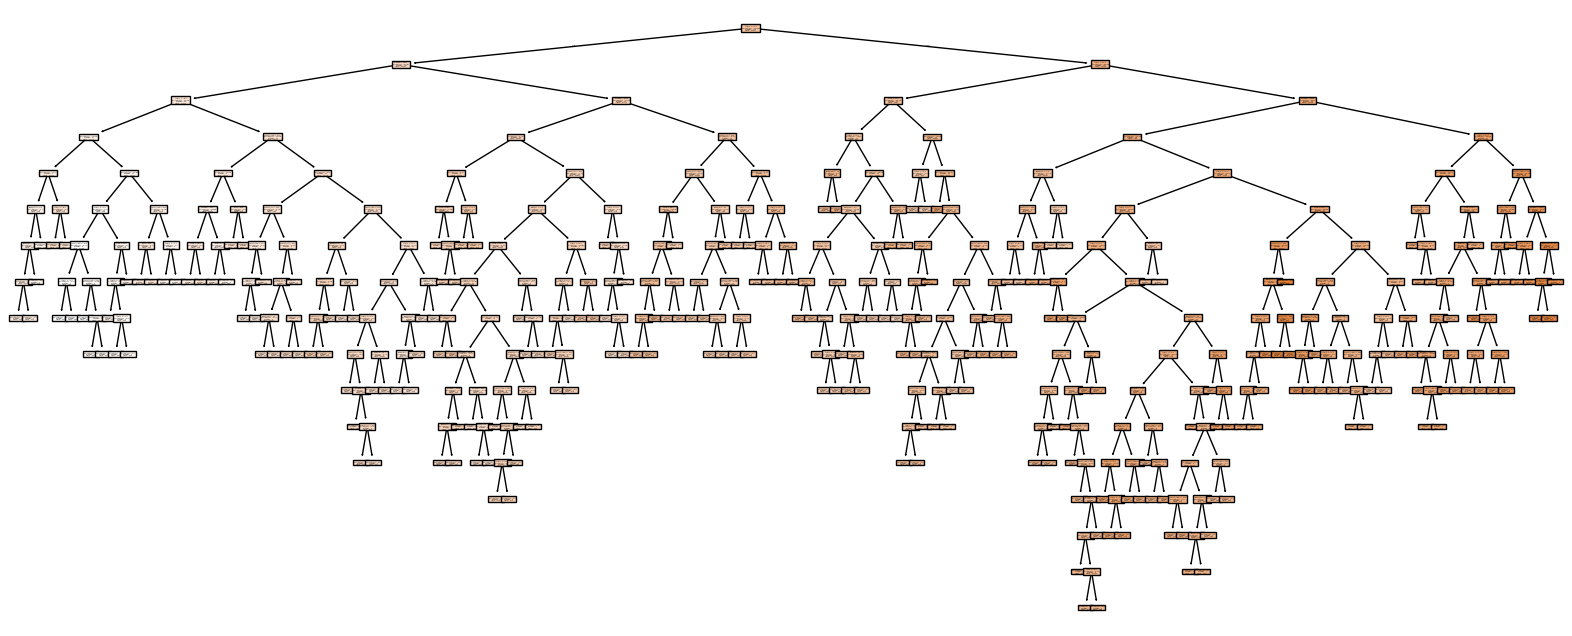

In [56]:
# importo librerías
import sklearn
import matplotlib.pyplot as plt
# visualizo el árbol de decisión
plt.figure(figsize=(20, 8))
sklearn.tree.plot_tree(arbol_regresion_seattle, feature_names=X.columns, filled=True)
plt.show()

#### Este gráfico es síntoma de overfitting. El modelo ha entrenado con tanto detalle, que no generaliza bien. Por ello hay que hacer el siguiente paso.

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [57]:
# creo un nuevo modelo de árbol de regresión con tres niveles máximos
arbol_regresion_seattle_3 = DecisionTreeRegressor(max_depth=3)
# entreno el nuevo modelo
arbol_regresion_seattle_3.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

### 8. Vuelve a evaluar tu modelo

In [58]:
# hago las predicciones
y_prediccion_3 = arbol_regresion_seattle_3.predict(X_test)

print("R²:  ", r2_score(y_test, y_prediccion_3))
print("MAE: ", mean_absolute_error(y_test, y_prediccion_3))
print("MAPE:", mean_absolute_percentage_error(y_test, y_prediccion_3))
print("MSE: ", mean_squared_error(y_test, y_prediccion_3))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_prediccion_3)))

R²:   0.7921058441287924
MAE:  4.254308906350133
MAPE: 0.06491876934915675
MSE:  29.45885645122262
RMSE: 5.427601353380941


#### Todas las métricas mejoran limitando la profundidad del árbol. Al hacerlo, el árbol deja de memorizar y generaliza mejor con datos nuevos. Menos complejidad = menos overfitting = mejores resultados con la parte de test.

### 9. Vuelve a representar su árbol

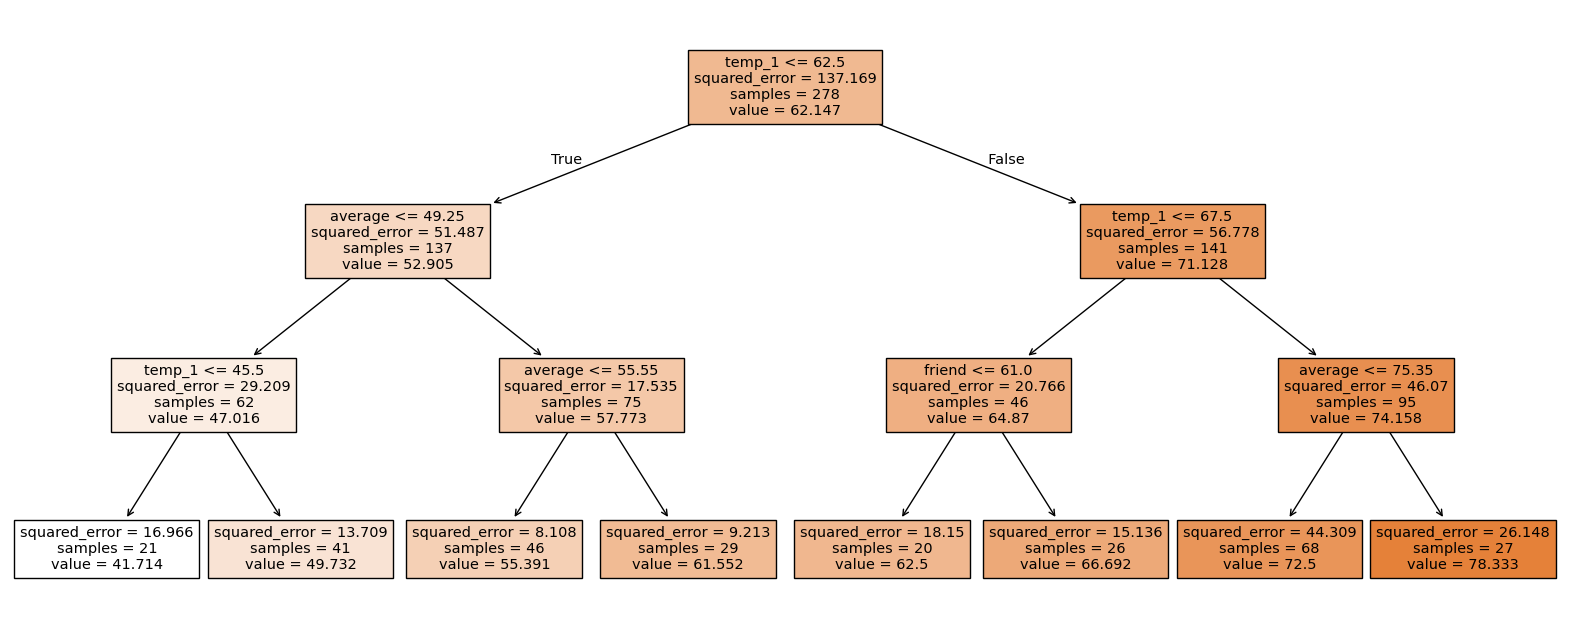

In [59]:
plt.figure(figsize=(20, 8))
sklearn.tree.plot_tree(arbol_regresion_seattle_3, feature_names=X.columns, filled=True)
plt.show()

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [60]:
# importo GridSearchCV para probar diferentes parámetros en el modelo
from sklearn.model_selection import GridSearchCV

# Parámetros que queremos probar
params = {
    'max_depth': [2, 3, 4, 5, 6], # profundidades máximas a probar
    'min_samples_leaf': [5, 10, 15], # número mínimo de nodos terminales a probar
    'criterion': ['squared_error', 'absolute_error'] # criterios de división a probar
}

# Hago el GridSearchCV 
grid_search = GridSearchCV(DecisionTreeRegressor(), # marco el modelo
                           params, # incluyo los parámetros apuntados anteriormente
                           cv=5, # número de trozos en los que dividimos el train
                           scoring='r2') # como r2 explica la variabilidad del modelo, esta métrica se usa para 
                                         # decidir qué parámetros son mejores

# entreno el GridSearchCV
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [61]:
# imprimo los mejores parámetros
print("Mejores parámetros:", grid_search.best_params_)
# imprimo el mejor R² en la validación cruzada
print("Mejor R² en CV:", grid_search.best_score_)

Mejores parámetros: {'criterion': 'absolute_error', 'max_depth': 4, 'min_samples_leaf': 15}
Mejor R² en CV: 0.8087261624385507


#### El GridSearch ha encontrado que la mejor combinación es:

* criterion='absolute_error': mejor tratar los errores por igual que penalizar los grandes
* max_depth=4: un nivel más que el que probamos antes
* min_samples_leaf=15: cada hoja necesita mínimo 15 muestras, evita hojas con muy pocos datos

#### Y el R² en CV = 0.808 implica que tenemos predicciones más fiables.

In [63]:
# creo un nuevo modelo con los mejores parámetros encontrados
mejor_modelo = grid_search.best_estimator_
# hago las predicciones con el mejor modelo
y_pred_mejor_modelo = mejor_modelo.predict(X_test)
# imprimo las métricas del mejor modelo
print("R²:  ", r2_score(y_test, y_pred_mejor_modelo))
print("MAE: ", mean_absolute_error(y_test, y_pred_mejor_modelo))
print("MAPE:", mean_absolute_percentage_error(y_test, y_pred_mejor_modelo))
print("MSE: ", mean_squared_error(y_test, y_pred_mejor_modelo))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_mejor_modelo)))

R²:   0.7871779657111255
MAE:  4.442857142857143
MAPE: 0.06736096935213924
MSE:  30.15714285714286
RMSE: 5.491551953422899


#### El GridSearch no ha mejorado mucho respecto a la solución manual, pero esto puede deberse a que, probablemente, el dataset es pequeño y el árbol tiene poco margen de mejora.

### 11. Obten el `feature_importances` de cada variable en el último modelo

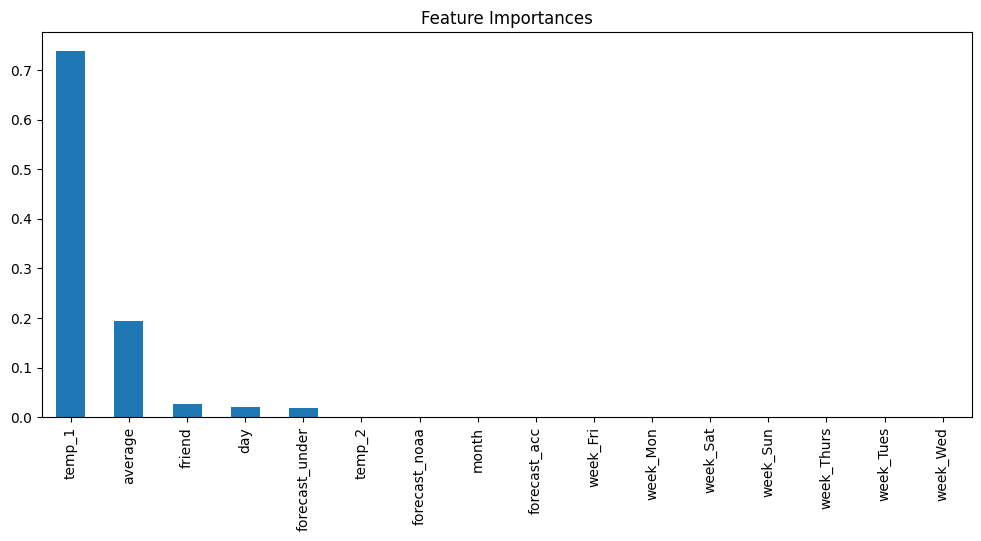

In [66]:
importancias = pd.Series(mejor_modelo.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title("Feature Importances");

#### Con este gráfico queda claro que la variable más importante para predecir la temperatura de mañana es la temperatura del día anterior. El histórico (average) también tiene importancia. Para sorpresa, la opinión del amigo tiene un poco de relevancia, así como day y forecast_under. El resto son variables irrelevantes para la predicción.

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC. ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [68]:
# defino de nuevo la variable objetivo, pero esta vez no como valores, sino como una clase (supera o no los 15°C, es decir, 59ºF)
# utilizo astype(int) para convertir los valores booleanos (True/False) en 1 y 0, que para los modelos son mejores
y_clase = (seattle['actual'] >= 59).astype(int)

In [74]:
# divido el dataset en entrenamiento y prueba para el nuevo modelo
X_train_clase, X_test_clase, y_train_clase, y_test_clase = train_test_split(X, y_clase, test_size=0.2, random_state=11)

In [75]:
# imprimo la distribución de la variable objetivo para ver si está balanceada o no
y_clase.value_counts(normalize=True)

actual
1    0.617816
0    0.382184
Name: proportion, dtype: float64

#### Hay una proporcion de 60% de días que hay más de 15ºC y 40% de días que hay menos de 15ºC. No es un mal balanceo.

In [76]:
# importo el modelo de árbol de decisión
from sklearn.tree import DecisionTreeClassifier
# defino los parámetros que quiero probar para el modelo
params_clase = {
    'max_depth': [2, 3, 4, 5, 6], # profundidades máximas a probar
    'min_samples_leaf': [5, 10, 15], # número mínimo de nodos terminales a probar
    'criterion': ['gini', 'entropy'] # criterios de división a probar
}

# hago el GridSearchCV para el modelo
grid_search_clase = GridSearchCV(DecisionTreeClassifier(),
                              params_clase,
                              cv=5, # número de trozos en los que dividimos el train
                              scoring='accuracy') # como accuracy mide el porcentaje de aciertos, 
                                                  # esta métrica se usa para decidir qué parámetros son mejores

In [77]:
# entreno el modelo 
grid_search_clase.fit(X_train_clase, y_train_clase)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >

In [85]:
# imprimo los mejores parámetros
print("Mejores parámetros:", grid_search_clase.best_params_)
# imprimo el mejor accuracy en la validación cruzada
print("Mejor accuracy:", grid_search_clase.best_score_)

Mejores parámetros: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}
Mejor accuracy: 0.9387662337662338


#### Muy buenos resultados: árbol poco profundo (max_depth=3) y con un accuracy de casi el 94%. Esto último significa que el modelo acierta casi 94 de cada 100 días que realiza predicciones.

In [ ]:
# guardo el mejor modelo
mejor_modelo_clase = grid_search_clase.best_estimator_
# hago las predicciones con el mejor modelo
y_pred_clase = mejor_modelo_clase.predict(X_test_clase)


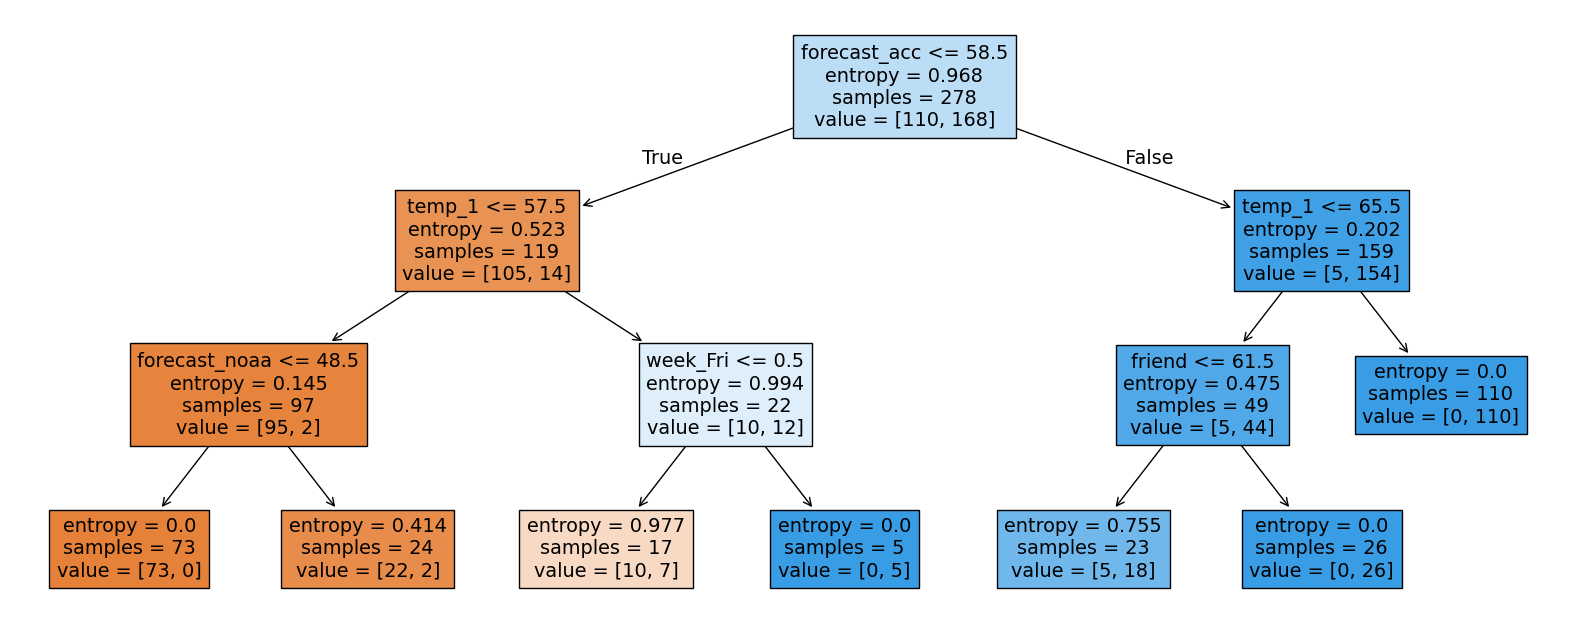

In [91]:
plt.figure(figsize=(20, 8))
sklearn.tree.plot_tree(mejor_modelo_clase, feature_names=X.columns, filled=True)
plt.show()

In [86]:
# importo las métricas para evaluar el modelo de clasificación
from sklearn.metrics import accuracy_score
# imprimo el accuracy del modelo de clasificación
print("Accuracy:", accuracy_score(y_test_clase, y_pred_clase))

Accuracy: 0.8428571428571429


#### En los test, el accuracy ha bajado al 84%. Esto significa que el modelo funciona mejor con los datos que ya conoce que con datos nuevos. Posible signo de overfitting.

In [87]:
# importo las métricas para evaluar el modelo de clasificación
from sklearn.metrics import classification_report
# imprimo el classification report del modelo de clasificación
print(classification_report(y_test_clase, y_pred_clase))

              precision    recall  f1-score   support

           0       0.70      0.91      0.79        23
           1       0.95      0.81      0.87        47

    accuracy                           0.84        70
   macro avg       0.82      0.86      0.83        70
weighted avg       0.87      0.84      0.85        70



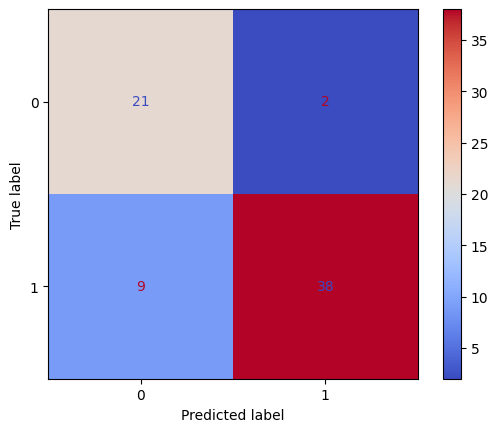

In [89]:
# importo la métrica para visualizar la matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay
# visualizo la matriz de confusión del modelo de clasificación
ConfusionMatrixDisplay.from_predictions(y_test_clase, y_pred_clase, cmap='coolwarm')

#### Tenemos dos falsos positivos y 9 falsos negativos. Es decir, que el modelo es bueno prediciendo, aunque en dos ocasiones predijo calor e hizo frío, mientras que en 9 ocasiones no logró predecir más de 15ºC. Se podría decir que este en un modelo bastante bueno para detectar los días de frío y de calor, acertando especialmente en los días calurosos.